# 02 — Physics-Based Modeling

This notebook implements the **physics half** of the digital twin: a thermal model
that predicts what the transformer's hotspot temperature *should* be under the
current loading and ambient conditions, and an Arrhenius aging model that
translates the thermal history into insulation life consumed.

**Why physics + ML together?** A purely ML approach needs vast amounts of training
data to learn equipment behavior from scratch. A purely physics approach captures
the known relationships but misses unmodeled phenomena (sensor drift, cooling
degradation, novel fault modes). Combining them — the physics model provides
*expected behavior*, the ML model interprets *deviations* — is how production-grade
industrial digital twins work.

**Standards implemented:**
- IEEE C57.91 (Guide for Loading Mineral-Oil-Immersed Transformers): hotspot temperature
- Arrhenius / Montsinger's rule: paper insulation aging

These are textbook models; real deployments would use higher-fidelity finite-element
thermal simulations and detailed loss-of-life integration.


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.physics import ThermalModel, AgingModel, EquivalentCircuit, fit_thermal_parameters
from src.visualization import setup_style, plot_residuals
setup_style()

df = pd.read_csv('../data/synthetic_transformer_telemetry.csv')
print(f"Loaded {len(df)} hourly observations")

Loaded 4320 hourly observations


## Thermal model — IEEE C57.91

The standard hotspot model is:

$$\theta_{hotspot} = \theta_{ambient} + \Delta\theta_{top\_oil\_rated} \cdot (load)^{1.6} + \Delta\theta_{hotspot\_rated} \cdot (load)^{2.0}$$

Default rated rises (typical of an ONAF-cooled transformer): top-oil 38 K, hotspot 17 K.
These would normally come from the unit's heat-run test report.


In [5]:
thermal = ThermalModel(delta_top_oil_rated=38.0, delta_hotspot_rated=17.0)

# Predict expected hotspot at every hour
df["predicted_hotspot_c"] = thermal.predict_hotspot(df["load_pu"], df["ambient_temp_c"])

# The KEY feature: residual = measured - predicted
df["hotspot_residual"] = df["winding_hotspot_c"] - df["predicted_hotspot_c"]

print(f"Mean residual: {df['hotspot_residual'].mean():.2f} C")
print(f"Std residual:  {df['hotspot_residual'].std():.2f} C")
print(f"Max residual:  {df['hotspot_residual'].max():.2f} C")

Mean residual: 0.09 C
Std residual:  1.24 C
Max residual:  11.62 C


### Visualize: measured vs predicted

The two curves should track each other closely during normal operation, and diverge during fault events. The bottom panel shows the residual — small under normal conditions, growing during faults.


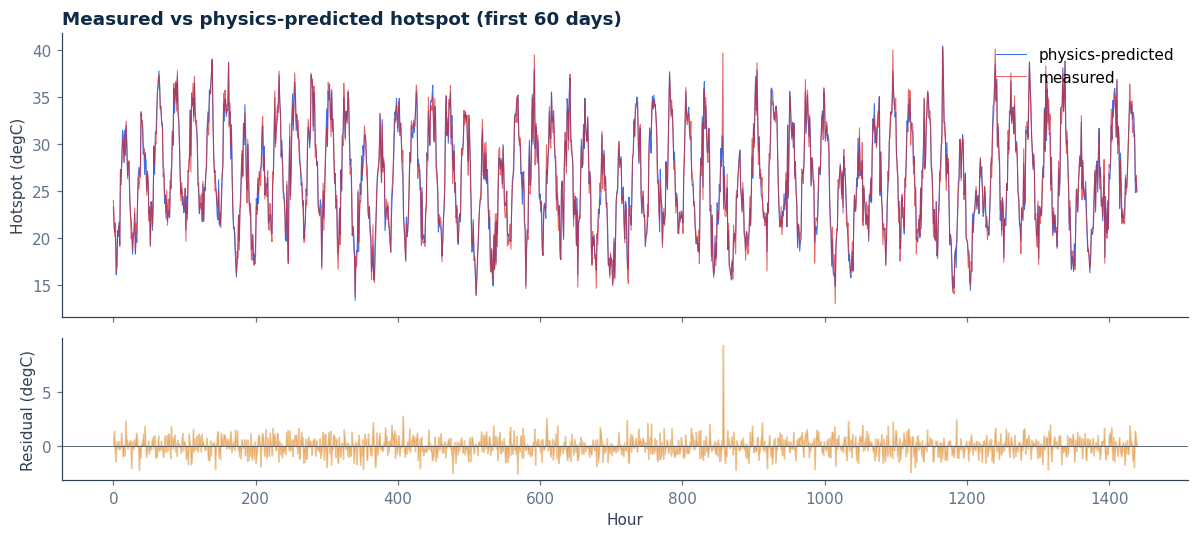

In [6]:
fig = plot_residuals(
    df["winding_hotspot_c"].values[:24*60],
    df["predicted_hotspot_c"].values[:24*60],
    title="Measured vs physics-predicted hotspot (first 60 days)"
)
plt.show()

## Aging model — Arrhenius

For mineral-oil paper insulation, the IEEE C57.91 aging acceleration factor is:

$$F_{AA} = \exp\left(\frac{15000}{383} - \frac{15000}{\theta_{hotspot}+273}\right)$$

At the reference temperature of 110°C, $F_{AA} = 1$. By Montsinger's rule it roughly doubles every 7°C — let's verify.


In [7]:
aging = AgingModel()
for temp in [80, 90, 100, 110, 117, 124, 130]:
    f_aa = aging.acceleration_factor(temp)
    print(f"  {temp:3d}C  ->  F_AA = {f_aa:6.3f}")

   80C  ->  F_AA =  0.036
   90C  ->  F_AA =  0.116
  100C  ->  F_AA =  0.350
  110C  ->  F_AA =  1.000
  117C  ->  F_AA =  2.020
  124C  ->  F_AA =  3.979
  130C  ->  F_AA =  6.984


### Cumulative life consumed

Integrating F_AA over the simulated 180 days gives total equivalent ageing hours. Compared to the 180,000-hour design life, this gives a physics-grounded estimate of insulation life used so far.


In [8]:
consumed_hours = aging.life_consumed_hours(df["winding_hotspot_c"].values, dt_hours=1.0)
remaining_pct = aging.life_remaining_pct(df["winding_hotspot_c"].values)

print(f"Equivalent ageing hours consumed in 180 days: {consumed_hours[-1]:.1f} hours")
print(f"Remaining insulation life: {remaining_pct[-1]:.2f}% of design life")
print(f"\nNote: this is a moderately-loaded unit. Heavily-loaded units consume life much faster.")

Equivalent ageing hours consumed in 180 days: 0.7 hours
Remaining insulation life: 100.00% of design life

Note: this is a moderately-loaded unit. Heavily-loaded units consume life much faster.


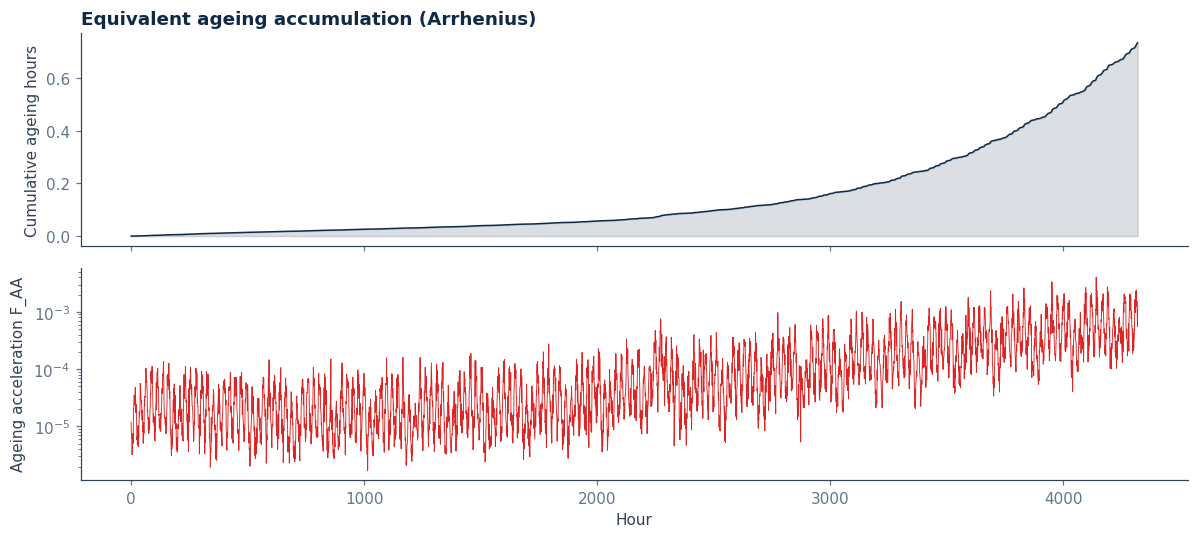

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax1.plot(consumed_hours, color="#0F2A47", linewidth=1)
ax1.fill_between(np.arange(len(consumed_hours)), 0, consumed_hours, color="#0F2A47", alpha=0.15)
ax1.set_ylabel("Cumulative ageing hours")
ax1.set_title("Equivalent ageing accumulation (Arrhenius)", loc="left")

f_aa_history = aging.acceleration_factor(df["winding_hotspot_c"].values)
ax2.plot(f_aa_history, color="#DC2626", linewidth=0.6)
ax2.set_ylabel("Ageing acceleration F_AA")
ax2.set_xlabel("Hour")
ax2.set_yscale("log")
plt.tight_layout()
plt.show()

## Equivalent circuit — what-if simulation

The standard T-equivalent allows us to simulate overload scenarios without actually applying them to the asset. This drives the "what-if" panel on the operator dashboard.


In [10]:
ec = EquivalentCircuit(rated_kva=25000, copper_loss_rated_kw=120, iron_loss_kw=25)

# What-if: push to 120% load for 4 hours during a hot day (35C ambient)
scenario = ec.simulate_overload(load_pu=1.2, duration_hours=4.0, ambient_c=35,
                                 thermal=thermal, aging=aging)
print("What-if: 120% load for 4 hours at 35C ambient")
for k, v in scenario.items():
    print(f"  {k}: {v}")

What-if: 120% load for 4 hours at 35C ambient
  load_pu: 1.2
  duration_hours: 4.0
  predicted_hotspot_c: 110.35138835088014
  aging_acceleration_factor: 1.0365511883836152
  equivalent_life_hours_consumed: 4.146204753534461
  exceeds_design_limit: False


## Validation — parameter refitting

If the physics model's parameters drift from reality (cooling degradation, calibration error), we can re-fit the rated rise values from observed data via least-squares.


In [11]:
fitted = fit_thermal_parameters(df.iloc[:2000])  # fit on first 2000 hours of normal data
print("Refitted thermal parameters (from observed data):")
for k, v in fitted.items():
    print(f"  {k}: {v:.2f}")

Refitted thermal parameters (from observed data):
  delta_top_oil_rated: 36.65
  delta_hotspot_rated: 18.62
  rmse_c: 0.95


## Next step

The residual we computed (measured - predicted hotspot) becomes a key feature in
notebook **03_anomaly_detection**, where an Isolation Forest learns to flag
operating states that are unusual *given current loading conditions* — not just
unusual in absolute terms.
